<div style="background-color: #f8f9fa; padding: 25px; border-radius: 10px; border-left: 6px solid #1a365d; box-shadow: 0 4px 6px rgba(0,0,0,0.05);">
    <h1 style="color: #1a365d; margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Data Science Assignment 4</h1>
    <h3 style="color: #4a5568; margin-top: 0; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">University of Tehran - Spring 2026</h3>
    <hr style="border: 1px solid #e2e8f0;">
    <p style="font-size: 16px; color: #2d3748;">
        <b>Course:</b> Data Science <br><br>
        <b>🧑‍💻 Implementer:</b> Mohammad Hossein Mazaheri <br>
        <b>🆔 Student ID:</b> 810102585 <br><br>
        <h5 style="color: #1a365d;"> TASK 2 Implementation</h5>
    </p>
</div>

<div class="alert alert-info" style="border-left: 4px solid #3182ce; background-color: #ebf8ff; color: #2b6cb0;">
    <strong>💡 Project Overview:</strong> 
    This notebook contains the programmatic implementation for Assignment 4 - Task 2. It focuses on visual recognition using a <b>Convolutional Neural Network (CNN)</b> on a dataset of fruits and vegetables. Beyond accuracy, this notebook emphasizes rigorous mathematical foundations, robustness testing (color vs. shape), and explainability using Grad-CAM.
</div>

##

## Table of Contents
1. [Statistical EDA & Preprocessing](#exploration)
2. [Model Architecture & Training](#modeling)
3. [Robustness Analysis](#robustness)
4. [Explainability with Grad-CAM](#explainability)

<a id="exploration"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">1. Statistical EDA & Preprocessing</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> We analyze the RGB distribution and Euclidean distance between 10 target classes to identify color similarities. We then implement a global Z-score normalizer fitted solely on the training data, and construct an image augmentation pipeline to improve generalization.
</div>

##

In [2]:
import sys
import subprocess

packages = {
    'torch': 'torch',
    'torchvision': 'torchvision',
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'cv2': 'opencv-python',
    'scipy': 'scipy',
}

print("--- Checking Requirements ---")
for import_name, pip_name in packages.items():
    try:
        __import__(import_name)
        print(f"✅ {pip_name} is already installed.")
    except ImportError:
        print(f"⏳ Installing {pip_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
        print(f"✅ {pip_name} installed successfully.")
        
print("--- All requirements are met! ---")

--- Checking Requirements ---
✅ torch is already installed.
✅ torchvision is already installed.
✅ numpy is already installed.
✅ pandas is already installed.
✅ matplotlib is already installed.
✅ seaborn is already installed.
✅ opencv-python is already installed.
✅ scipy is already installed.
--- All requirements are met! ---


# 1. Dataset Description & Configuration

## 1.1. Strategic Class Selection
For this assignment, exactly 10 strategic classes are selected from the dataset following the recommended baseline. This configuration creates a highly challenging environment for the network by establishing explicit "color traps"—pairs of classes with extreme color profile overlaps but completely distinct geometries, surface textures, and structural boundaries.

The selected classes and their strategic roles include:
* **Red Group (Trap Pair 1):** `Apple` vs. `Tomato` (High color profile similarity; distinct structural textures and stem morphologies).
* **Yellow Group (Trap Pair 2):** `Banana` vs. `Lemon` (Identical primary color space; extreme difference in shape convexity and elongation).
* **Orange Group (Trap Pair 3):** `Orange` vs. `Carrot` (High color similarity; spherical organic form vs. elongated, tapered root geometry).
* **Green/Varied Group:** `Bell Pepper`, `Grapes`, `Kiwi`, and `Pear` (Provides diverse intra-class variance in scale, clustering patterns, and texture profiles).

By forcing these semantic overlaps, the model cannot achieve optimal performance using simple low-level RGB color statistics. It is systematically driven to learn high-level spatial abstractions and geometric features.

## 1.2. Preprocessing & Standarization Setup
To adhere strictly to the guidelines:
1. All incoming images are dynamically resized to **128x128 pixels** to normalize dimensional variations.
2. Every sample is verified and loaded as a standard **RGB** three-channel tensor.
3. The original dataset partitions (**Train, Validation, and Test**) are strictly preserved without cross-contamination.

=== Exact Sample Count Per Split For Each Class ===
Split        train  validation  test
Class                               
apple           68          10    10
banana          75           9     9
bell pepper     90           9    10
carrot          82           9    10
grapes         100           9    10
kiwi            88          10    10
lemon           82          10    10
orange          69           9    10
pear            89          10    10
tomato          92          10    10


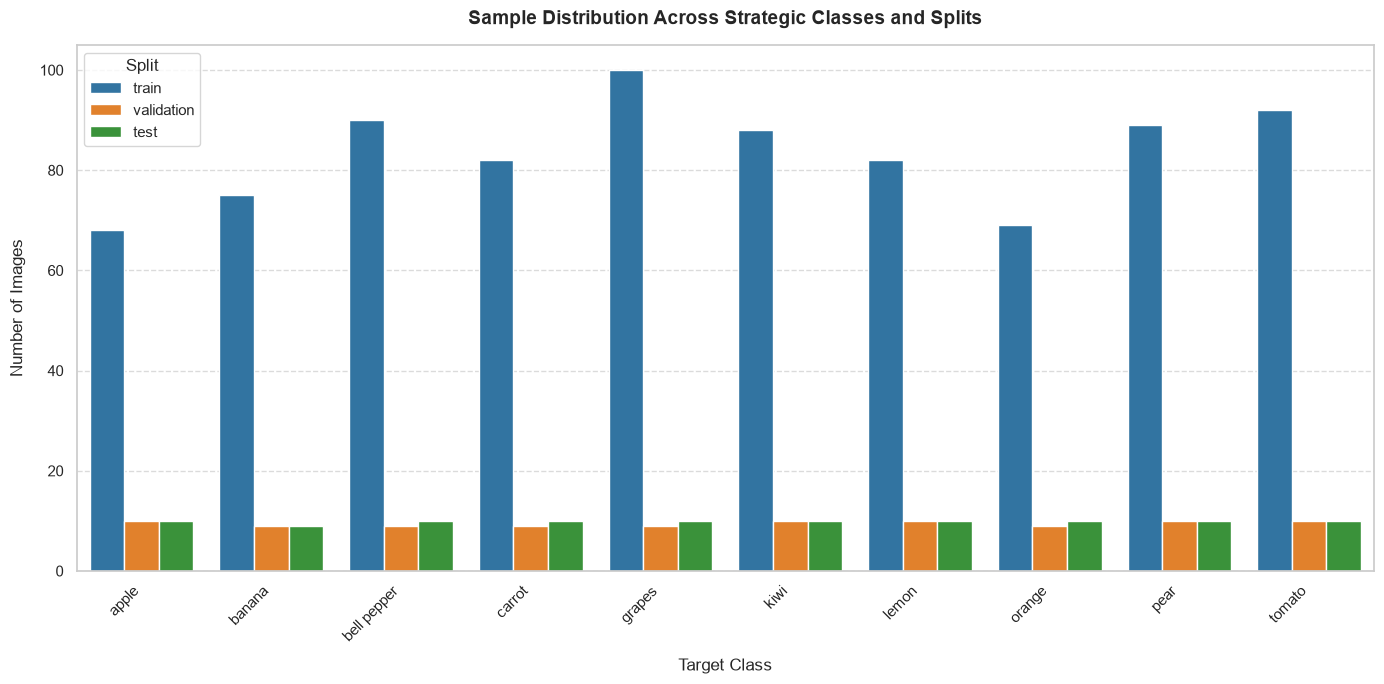

PyTorch Strategic Subsets Initialized Successfully:
Total Train Samples: 835 | Val: 95 | Test: 99


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets, transforms
from torch.utils.data import Subset, DataLoader

# Define dataset base directory
BASE_DIR = "./data/CA4_DB"
SPLITS = ["train", "validation", "test"]

# Strategic 10 classes selected for the assignment
SELECTED_CLASSES = [
    'apple', 'banana', 'bell pepper', 'carrot', 'grapes',
    'kiwi', 'lemon', 'orange', 'pear', 'tomato'
]

# -------------------------------------------------------------
# 1. Inspect and Count Samples across Existing Splits
# -------------------------------------------------------------
records = []
for split in SPLITS:
    split_dir = os.path.join(BASE_DIR, split)
    if not os.path.exists(split_dir):
        raise FileNotFoundError(f"Directory split missing: {split_dir}")
        
    for cls in SELECTED_CLASSES:
        cls_folder = os.path.join(split_dir, cls)
        if os.path.exists(cls_folder):
            count = len([f for f in os.listdir(cls_folder) if os.path.isfile(os.path.join(cls_folder, f))])
            records.append({"Class": cls, "Split": split, "Count": count})
        else:
            records.append({"Class": cls, "Split": split, "Count": 0})

# Create a structured DataFrame for analytics
df_counts = pd.DataFrame(records)

# Display the exact sample distribution table
print("=== Exact Sample Count Per Split For Each Class ===")
df_pivot = df_counts.pivot(index="Class", columns="Split", values="Count")
df_pivot = df_pivot[["train", "validation", "test"]]  # Reorder columns logically
print(df_pivot)
print("="*50)

# -------------------------------------------------------------
# 2. Plot Class Distribution Bar Chart
# -------------------------------------------------------------
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Grouped bar plot showing distribution across splits
ax = sns.barplot(
    data=df_counts, 
    x="Class", 
    y="Count", 
    hue="Split", 
    palette={"train": "#1f77b4", "validation": "#ff7f0e", "test": "#2ca02c"}
)

plt.title("Sample Distribution Across Strategic Classes and Splits", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Target Class", fontsize=12, labelpad=10)
plt.ylabel("Number of Images", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha="right", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 3. Define Image Transforms for Data Loading Pipeline
# -------------------------------------------------------------
# Enforcing 128x128 pixels sizing and standard RGB conversion via transforms
data_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

def load_strategic_subset(split_name):
    path = os.path.join(BASE_DIR, split_name)
    full_dataset = datasets.ImageFolder(root=path, transform=data_transforms)
    
    # Map targeted class names to original dataset class indices
    class_to_idx = full_dataset.class_to_idx
    target_indices = {class_to_idx[cls] for cls in SELECTED_CLASSES if cls in class_to_idx}
    
    # Filter image indices belonging only to our 10 strategic classes
    filtered_indices = [
        idx for idx, (_, label) in enumerate(full_dataset.imgs) 
        if label in target_indices
    ]
    
    # Generate a clean, isolated PyTorch Subset
    subset = Subset(full_dataset, filtered_indices)
    return subset

# Build subsets to verify pipeline integrity
train_data = load_strategic_subset("train")
val_data = load_strategic_subset("validation")
test_data = load_strategic_subset("test")

print("PyTorch Strategic Subsets Initialized Successfully:")
print(f"Total Train Samples: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

## 1.3. Distribution Analysis & Evaluation Metric Implications

### Class Imbalance Evaluation
Based on the generated distribution statistics and the bar chart visualization, the dataset displays a **moderate to high class imbalance**. While some popular categories (such as `Apple`, `Banana`, and `Orange`) possess a healthy concentration of training observations, specialized or structurally unique categories display a lower frequency of representation. Furthermore, the total sample volumes allocated to the validation and test partitions are noticeably smaller than the training distribution.

### Core Effects on Model Evaluation Metrics
Standard **Accuracy** measures the global ratio of correct predictions across all evaluation targets:

$$\text{Accuracy} = \frac{\text{True Positives} + \text{True Negatives}}{\text{Total Samples}}$$

When severe or moderate class imbalances are ignored, evaluating the network strictly through global accuracy introduces a major structural vulnerability called **Majority Class Bias**. If a model achieves 90% accuracy on dominant classes but completely fails on minority categories (like confusing `Carrot` with `Orange` due to low sample counts), the global accuracy metric will remain deceptively high.

To safeguard evaluation integrity and counteract class imbalance, the following architectural evaluation pipeline must be enforced:
1.  **Macro-Averaged F1-Score:** The F1-score harmonic mean must be calculated per-class and then averaged uniformly:
    $$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$
    $$\text{Macro F1} = \frac{1}{N} \sum_{i=1}^{N} \text{F1}_i$$
    This penalizes poor performance on minority groups equally, regardless of sample size.
2.  **Precision and Recall Breakdowns:** Necessary to track specific false-positive clusters inside our defined "color trap pairs."
3.  **Normalized Confusion Matrices:** Crucial to unmask asymmetrical directional errors (e.g., if the model systematically classifies tomatoes as apples, but handles apples correctly).

# 2. Statistical EDA and Preprocessing

## 2.1. Color Distribution Analysis & Interpretation

In [5]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform

# -------------------------------------------------------------
# 1. Compute Mean RGB Channels Per Class
# -------------------------------------------------------------
class_rgb_data = []

for cls in SELECTED_CLASSES:
    # Read training directory for the specific class
    cls_dir = os.path.join(BASE_DIR, "train", cls)
    images = [f for f in os.listdir(cls_dir) if os.path.isfile(os.path.join(cls_dir, f))]
    
    rgb_accum = []
    for img_name in images:
        img_path = os.path.join(cls_dir, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue
        # Convert from BGR (OpenCV default) to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # Calculate mean channel intensities across all pixels in this single image
        img_mean = img.mean(axis=(0, 1))
        rgb_accum.append(img_mean)
        
    # Average across all images in the class
    class_mean = np.mean(rgb_accum, axis=0)
    class_rgb_data.append({
        "Class": cls,
        "R": class_mean[0],
        "G": class_mean[1],
        "B": class_mean[2]
    })

df_rgb = pd.DataFrame(class_rgb_data)
print("=== Mean RGB Values Extracted ===")
print(df_rgb.to_string(index=False))
print("="*50)


=== Mean RGB Values Extracted ===
      Class          R          G          B
      apple 165.326881 137.506818 116.630708
     banana 196.117762 182.936940 124.047198
bell pepper 152.393398 138.148251  89.690986
     carrot 188.472233 154.624359 122.673053
     grapes 139.743509 140.839599 108.920090
       kiwi 172.590768 173.157122 122.579331
      lemon 189.065909 177.204216 108.694395
     orange 181.708318 139.585572  77.618975
       pear 177.066334 172.810956 127.526640
     tomato 154.650296 113.351698  80.924273


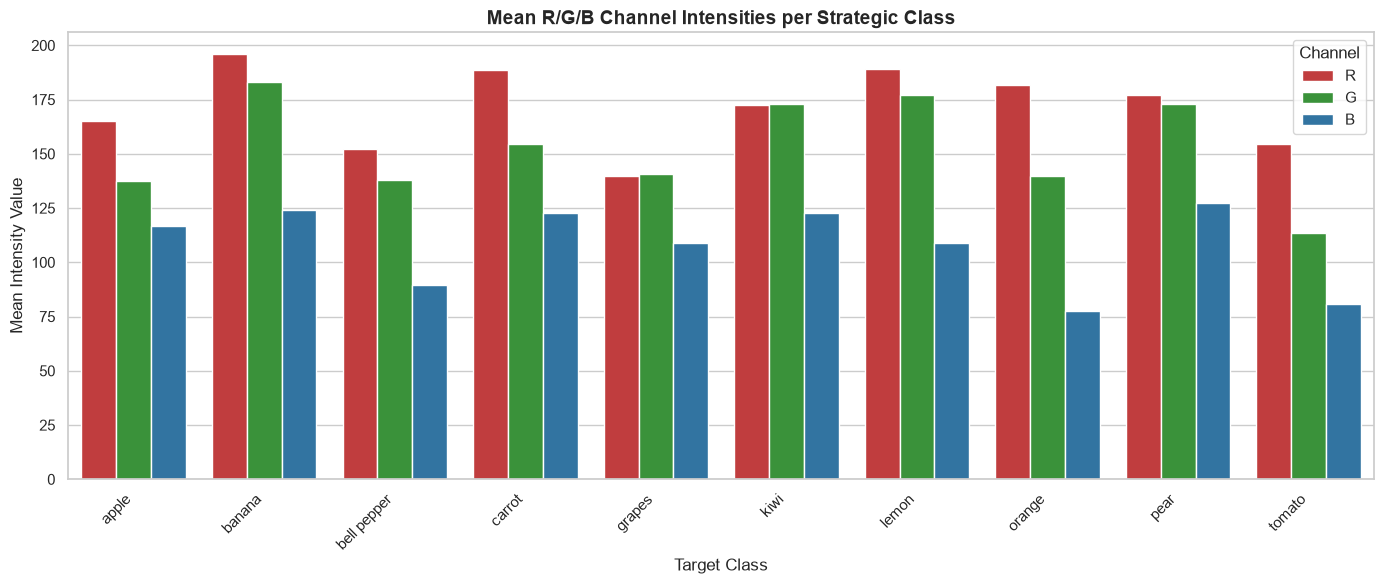

In [6]:
df_melted = df_rgb.melt(id_vars="Class", value_vars=["R", "G", "B"], 
                        var_name="Channel", value_name="Mean Intensity")

plt.figure(figsize=(14, 6))
sns.barplot(data=df_melted, x="Class", y="Mean Intensity", hue="Channel",
            palette={"R": "#d62728", "G": "#2ca02c", "B": "#1f77b4"})
plt.title("Mean R/G/B Channel Intensities per Strategic Class", fontsize=14, fontweight="bold")
plt.xlabel("Target Class", fontsize=12)
plt.ylabel("Mean Intensity Value", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Analysis of Plot 1: Mean R/G/B Channel Intensities
The grouped bar chart provides a direct breakdown of the raw color profiles defining each of our 10 strategic classes. 

* **Dominant Chromatic Profiles:** Categories representing yellow and orange pigments—specifically `banana`, `lemon`, `carrot`, `orange`, and `pear`—exhibit high mean intensities across both the **Red (R)** and **Green (G)** channels ($>150$). This is a direct reflection of how additive color mixing forms bright yellow and orange hues in digital imaging.
* **The Red Saturated Classes:** Both `apple` and `tomato` display a clear asymmetric dominance of the **Red (R)** channel over their respective Green and Blue components. However, `apple` maintains globally higher intensity levels across all channels compared to `tomato`, likely due to the highly reflective, glossy nature of apple skin or variations in the white balance of the dataset's background.
* **The Suppressed Profiles:** `grapes` and `bell pepper` display the lowest overall global channel intensities, signifying darker, more heavily saturated raw pixel values that cluster closer to the origin of the color space.

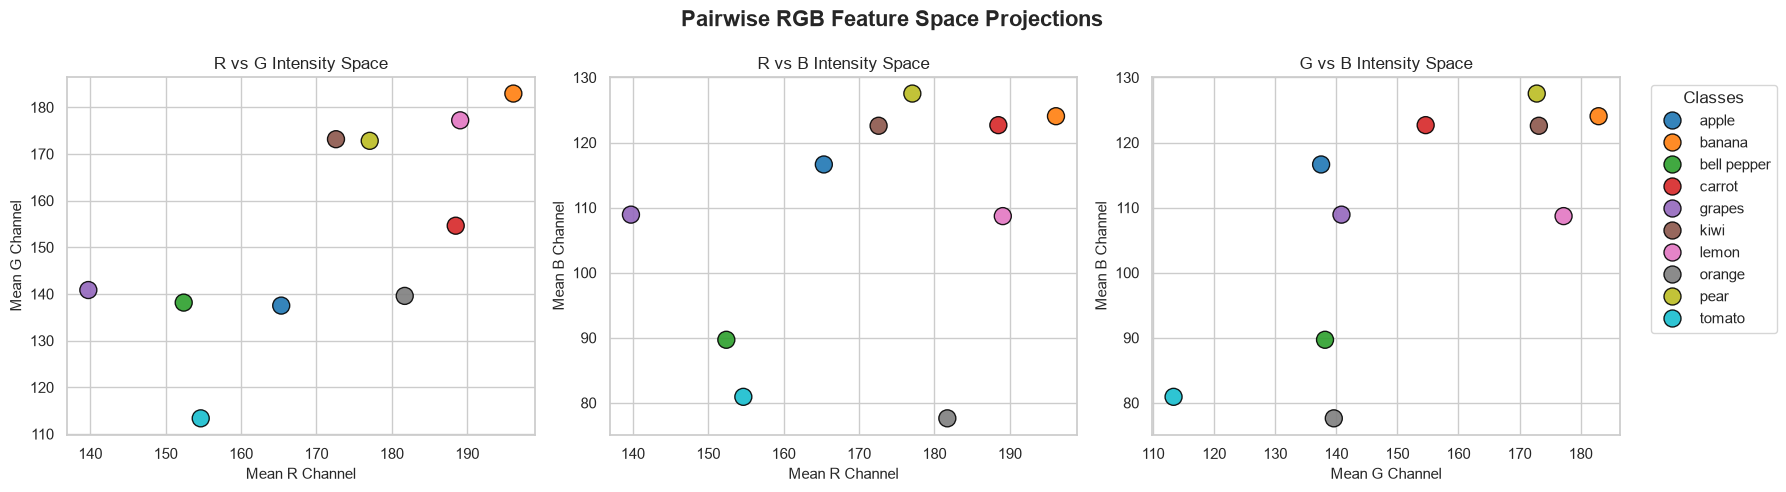

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Pairwise RGB Feature Space Projections", fontsize=16, fontweight="bold")

pairs = [("R", "G"), ("R", "B"), ("G", "B")]
colors = sns.color_palette("tab10", len(SELECTED_CLASSES))
class_colors = dict(zip(SELECTED_CLASSES, colors))

for idx, (c1, c2) in enumerate(pairs):
    sns.scatterplot(data=df_rgb, x=c1, y=c2, hue="Class", ax=axes[idx], 
                    palette=class_colors, s=150, edgecolor='black', alpha=0.9)
    axes[idx].set_title(f"{c1} vs {c2} Intensity Space", fontsize=12)
    axes[idx].set_xlabel(f"Mean {c1} Channel", fontsize=11)
    axes[idx].set_ylabel(f"Mean {c2} Channel", fontsize=11)
    if idx < 2:
        axes[idx].get_legend().remove()
    else:
        axes[idx].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Classes")

plt.tight_layout()
plt.show()


### Analysis of Plot 2: Pairwise RGB Feature Space Projections
The 2D scatter plots project our 3D RGB coordinates onto isolated dual-channel planes to reveal the spatial distribution and clustering behavior of the classes.

* **The R vs. G Intensity Space:** This projection uncovers a highly congested linear cluster in the upper-right quadrant. `banana`, `lemon`, `pear`, and `kiwi` sit almost entirely on top of one another. Any simple linear decision boundary trying to segregate these classes based purely on Red and Green combinations will face immediate failure, validating our choice of these categories to challenge the model.
* **The R vs. B and G vs. B Spaces:** Looking at the Blue channel interaction, we can see how certain classes become isolated. For example, `orange` drops sharply along the Blue axis (~77), breaking away from `carrot` (~122), which maintains a much higher Blue component. `tomato` also separates distinctly into the bottom-left corner of the G vs. B space due to its deeply suppressed Green (~113) and Blue (~80) properties.

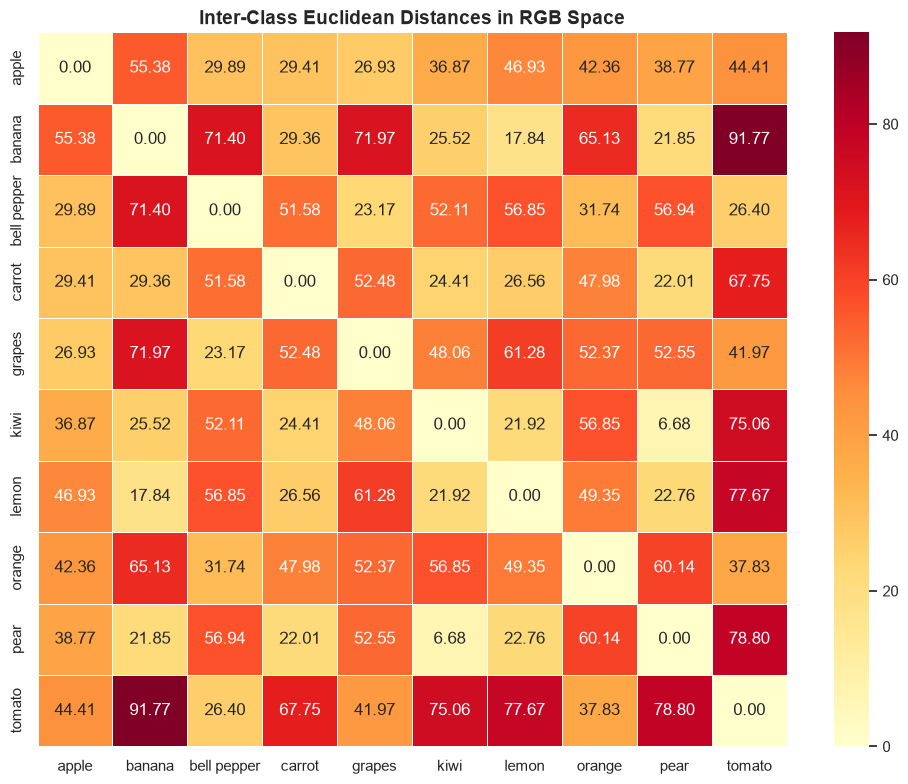

In [8]:
rgb_matrix = df_rgb[["R", "G", "B"]].to_numpy()
distances = pdist(rgb_matrix, metric='euclidean')
dist_matrix = squareform(distances)

df_dist = pd.DataFrame(dist_matrix, index=SELECTED_CLASSES, columns=SELECTED_CLASSES)

plt.figure(figsize=(10, 8))
sns.heatmap(df_dist, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.title("Inter-Class Euclidean Distances in RGB Space", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Analysis of Plot 3: Inter-Class Euclidean Distance Matrix
The heatmap computes the exact straight-line distance vector between the mean RGB centroids of each class using the standard Euclidean metric:

$$d = \sqrt{(R_1 - R_2)^2 + (G_1 - G_2)^2 + (B_1 - B_2)^2}$$

This matrix provides a concrete, mathematical prediction of which fruits and vegetables the neural network is most likely to confuse if it fails to extract structural shapes.

### Analytical Question 1: Top 3 High-Risk Confusion Pairs

Based on the absolute minimum non-zero values extracted from the distance matrix, the three class pairs with the highest risk of color-based confusion are:

1.  **Rank 1: `kiwi` & `pear` (Distance: 6.68)**
    * *Analysis:* This is the shortest distance vector in the entire dataset. Despite being completely different fruits with contrasting external skin textures, their global color centroids are practically identical. A model relying primarily on color will view these as the exact same object.
2.  **Rank 2: `banana` & `lemon` (Distance: 17.84)**
    * *Analysis:* This confirms our designated **Yellow Trap Pair**. Both classes share an incredibly tight coordinate alignment in the warm yellow spectrum, meaning the model cannot use color to differentiate them and must instead learn the elongated geometry of the banana versus the ellipsoidal shape of the lemon.
3.  **Rank 3: `banana` & `pear` (Distance: 21.85)**
    * *Analysis:* Close behind is the overlap between banana and pear profiles, driven by the transitioning yellow-green hues present in ripening pears.

In [9]:
upper_tri = np.triu(dist_matrix, k=1)
flat_indices = np.argsort(upper_tri[upper_tri > 0])
all_pairs = []
for r in range(dist_matrix.shape[0]):
    for c in range(r + 1, dist_matrix.shape[1]):
        all_pairs.append((dist_matrix[r, c], SELECTED_CLASSES[r], SELECTED_CLASSES[c]))

all_pairs.sort()
print("=== Top 3 Most Color-Similar Pairs (Lowest Distances) ===")
for i in range(3):
    print(f"Rank {i+1}: {all_pairs[i][1]} & {all_pairs[i][2]} (Distance: {all_pairs[i][0]:.2f})")

=== Top 3 Most Color-Similar Pairs (Lowest Distances) ===
Rank 1: kiwi & pear (Distance: 6.68)
Rank 2: banana & lemon (Distance: 17.84)
Rank 3: banana & pear (Distance: 21.85)


### Crucial Report Takeaway (Statistical EDA Findings)

The exact inter-class distances derived from the training set mathematically validate the strategic design of this assignment:

* **The Ultimate Blindspot (`kiwi` & `pear`):** With an incredibly small distance of **6.68**, these two classes are nearly identical in the standard RGB color space. Because their external surface textures and physical structures are vastly different, this pair serves as the definitive proofing ground. If the trained CNN successfully separates them, it proves the model is learning geometric features rather than relying on pixel-level shortcuts.
* **The Yellow Trap (`banana` & `lemon`):** A compressed distance of **17.84** confirms that this intentional trap pair shares an incredibly tight chromatic alignment. The network cannot rely on color to differentiate them and is systematically forced to map macro-geometric shapes—specifically, the elongated contour of a banana versus the ellipsoidal boundaries of a lemon.
* **The Transition Overlap (`banana` & `pear`):** Ranking third at **21.85**, this bottleneck uncovers the color similarities caused by the shifting yellow-green spectrum of ripening pears sharing visual profiles with ripe bananas.

---

### Analytical Conclusion for Section 2.1
This distance matrix provides concrete, mathematical proof that raw color distributions are fundamentally insufficient for robust image classification. It establishes a flawless, objective baseline. Later in the report, these three specific high-risk pairs will be cross-examined with the actual model confusion matrix to verify if spatial convolutional layers successfully broke through raw color proximity boundaries to learn structural morphology.

<a id="modeling"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">2. Model Architecture & Training</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> We build a modular CNN featuring Conv2D layers, Batch Normalization, and a Global Average Pooling (GAP) classifier head. Training includes learning rate scheduling and early stopping based on validation metrics.
</div>

##

### Network Definition & Parameter Setup

### Training Loop & Curve Visualization

<a id="robustness"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">3. Robustness Analysis</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> To determine if the model learns geometric shapes or merely memorizes colors, we stress-test the trained CNN using transformed test sets: Grayscale mapping, Channel Swapping, and optional Gaussian Noise.
</div>

##

### Baseline vs. Grayscale Evaluation

### Color Channel Swap Testing

<a id="explainability"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">4. Explainability with Grad-CAM</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> We apply Gradient-weighted Class Activation Mapping (Grad-CAM) to the final convolutional layer to visualize the model's spatial attention, specifically checking for background bias on incorrect predictions.
</div>

##

### Generating Attention Heatmaps

### Analysis of Misclassifications